# Sztuczne sieci neuronowe i głębokie uczenie - Sprawozdanie z laboratorium 8, Emilia Morawska

## Temat:

Praca z korpusami językowymi

### Cel ćwiczenia:

Celem laboratorium jest eksploracyjna analiza statystyczna polskojęzycznego korpusu Wikipedii oraz empiryczna weryfikacja prawa Zipfa i struktur N-gramowych. Ćwiczenie służy także ocenie efektywności subwyrazowych strategii tokenizacji (HerBERT vs mBERT) w kontekście ograniczeń okna kontekstowego modeli architektury Transformer.

### Wykorzystane narzędzia:

Colab, Python 3.14, HuggingFace (datasets, transformers, tokenizers), pandas, matplotlib, numpy, stop_words, re, collections (Counter)


In [ ]:
import re, math, warnings
warnings.filterwarnings('ignore')
from collections import Counter
from itertools import islice
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

wiki = load_dataset('wikimedia/wikipedia', '20231101.pl', split='train', streaming=True)
articles = list(islice(wiki, 200))
texts  = [a['text']  for a in articles]
titles = [a['title'] for a in articles]
print(f"Załadowano {len(texts)} artykułów.")

README.md:   0%|          | 0.00/131k [00:00<?, ?B/s]

Załadowano 200 artykułów.


### Zadanie 1: Pierwsza eksploracja korpusu
Korzystajac z zaladowanych 200 artykulow Wikipedii PL:

* Wyswietl tytuły pierwszych 10 artykulow.
* Dla kazdego z 10 artykulow wydrukuj: tytul, liczbe slow, pierwsze 2 zdania tekstu.
* Znajdz i wyswietl: najkrotszy i najdluzszy artykul (w slowach).
* W komórce Markdown: czym rozni sie korpus jezykowy od zbioru danych do
klasyfikacji?
(odpowiedz wlasnym slowami, 3–5 zdan)

In [ ]:
import re
from itertools import islice

first10_titles = titles[:10]
print("Tytuły pierwszych 10 artykułów:")
for i,t in enumerate(first10_titles,1):
    print(f"{i}. {t}")
print()


def split_sentences(text):
    s = re.split(r'(?<=[\.\!\?])\s+', text.strip())
    s = [ss.strip() for ss in s if ss.strip()]
    return s

print("Dla pierwszych 10 artykułów: tytuł, liczba słów, pierwsze 2 zdania:")
for i in range(10):
    title = titles[i]
    text = texts[i] if texts[i] is not None else ""
    # liczba słów (proste rozdzielenie po whitespace)
    word_count = len(re.findall(r'\S+', text))
    sentences = split_sentences(text)
    first_two = " ".join(sentences[:2]) if sentences else ""
    print(f"{i+1}. {title}")
    print(f"   Liczba słów: {word_count}")
    print(f"   Pierwsze 2 zdania: {first_two}")
    print()

word_counts = [len(re.findall(r'\S+', t if t else "")) for t in texts]
min_idx = int(np.argmin(word_counts))
max_idx = int(np.argmax(word_counts))
print("Najkrótszy artykuł (w słowach):")
print(f" Tytuł: {titles[min_idx]}")
print(f" Liczba słów: {word_counts[min_idx]}")
print()
print("Najdłuższy artykuł (w słowach):")
print(f" Tytuł: {titles[max_idx]}")
print(f" Liczba słów: {word_counts[max_idx]}")


Tytuły pierwszych 10 artykułów:
1. AWK
2. Alergologia
3. ASCII
4. Atom
5. Aksjomat
6. Arytmetyka
7. Alkeny
8. ActiveX
9. Interfejs programowania aplikacji
10. AmigaOS

Dla pierwszych 10 artykułów: tytuł, liczba słów, pierwsze 2 zdania:
1. AWK
   Liczba słów: 1661
   Pierwsze 2 zdania: AWK – interpretowany język programowania, którego główną funkcją jest wyszukiwanie i przetwarzanie wzorców w plikach lub strumieniach danych. Jest także nazwą programu początkowo dostępnego dla systemów operacyjnych będących pochodnymi UNIX-a, obecnie także na inne platformy.

2. Alergologia
   Liczba słów: 52
   Pierwsze 2 zdania: Alergologia – dziedzina medycyny zajmująca się rozpoznawaniem i leczeniem schorzeń alergicznych, czyli takich, u podstaw których stoi zjawisko nadwrażliwości, zwłaszcza inicjowane przez mechanizmy immunologiczne. W Polsce konsultantem krajowym alergologii od 19 lutego 2020 jest prof.

3. ASCII
   Liczba słów: 1545
   Pierwsze 2 zdania: ASCII (czyt. aski, skrót od ang.

4. Atom


Czym rozni sie korpus jezykowy od zbioru danych do klasyfikacji?

Główna różnica między korpusem językowym a zbiorem danych do klasyfikacji tkwi w ich przeznaczeniu oraz stopniu ustrukturyzowania informacji. Korpus stanowi naturalny, reprezentatywny zestaw tekstów, który służy jako surowy materiał empiryczny do globalnych analiz lingwistycznych lub bezwyznacznikowego modelowania języka. Z kolei zbiór klasyfikacyjny jest narzędziem ściśle sformatowanym pod paradygmat uczenia nadzorowanego; każdy zawarty w nim dokument musi posiadać przypisaną, jednoznaczną etykietę (klasę decyzyjną). Podczas gdy celem budowy korpusu jest wierne odzwierciedlenie autentycznego rozkładu i różnorodności mowy, zbiór do klasyfikacji jest zorientowany wyłącznie na optymalizację skuteczności modelu w konkretnym zadaniu predykcyjnym.

### Zadanie 2: Statystyki leksykalne i prawo Zipfa

Na pelnym zbiorze 200 artykulow:
* Polacz wszystkie teksty, przeprowadz prosta tokenizacje (split po bialych znakach,
lowercase, usun interpunkcje za pomoca re.sub).
* Oblicz i wyswietl: laczna liczba tokenow, liczba unikalnych tokenow (types), TTR.
* Wyswietl 20 najczestszych i 20 najrzadziej wystepujacych slow.
* Narysuj wykres prawa Zipfa: os X = ranga (log), os Y = czestotliwosc (log).

Na wykresie powinna wyjsc w przyblizeniu linia prosta — jesli nie, sprawdz tokenizacje.

Liczba tokenów (total): 220552
Liczba unikalnych tokenów (types): 49246
TTR (type-token ratio): 0.223285

20 najczęstszych tokenów:
w	8761
i	5379
z	3676
na	3343
się	2760
do	2543
jest	1556
a	1189
przez	1022
nie	1012
roku	990
od	928
o	928
to	862
że	806
oraz	796
po	734
są	642
jako	618
za	603

20 najrzadziej występujących tokenów:
--file	1
-0	1
-110	1
-a	1
-ac	1
-aib	1
-archos	1
-dien	1
-en	1
-in	1
-logiā	1
-monofosforan	1
-ol	1
-pierścień	1
-tetraen	1
-trien	1
-v	1
-wsch	1
-yn	1
-zach	1


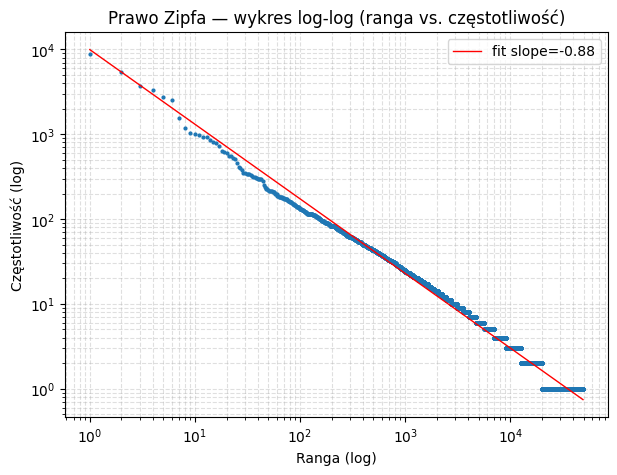

In [ ]:
import re
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt


all_text = " ".join(t for t in texts if t)


clean = re.sub(r'[^\wąęćłńóśźżĄĘĆŁŃÓŚŹŻ-]+', ' ', all_text)
clean = clean.lower().strip()
tokens = clean.split()


total_tokens = len(tokens)
types = set(tokens)
unique_tokens = len(types)
ttr = unique_tokens / total_tokens if total_tokens > 0 else 0.0

print(f"Liczba tokenów (total): {total_tokens}")
print(f"Liczba unikalnych tokenów (types): {unique_tokens}")
print(f"TTR (type-token ratio): {ttr:.6f}")


freq = Counter(tokens)
most20 = freq.most_common(20)

least20 = sorted(freq.items(), key=lambda x: (x[1], x[0]))[:20]

print("\n20 najczęstszych tokenów:")
for tok, c in most20:
    print(f"{tok}\t{c}")

print("\n20 najrzadziej występujących tokenów:")
for tok, c in least20:
    print(f"{tok}\t{c}")


freqs_sorted = np.array([c for _, c in freq.most_common()])
ranks = np.arange(1, len(freqs_sorted) + 1)


plt.figure(figsize=(7,5))
plt.loglog(ranks, freqs_sorted, marker='.', markersize=4, linewidth=0)
plt.xlabel('Ranga (log)')
plt.ylabel('Częstotliwość (log)')
plt.title('Prawo Zipfa — wykres log-log (ranga vs. częstotliwość)')
plt.grid(True, which="both", ls="--", alpha=0.4)

log_r = np.log(ranks)
log_f = np.log(freqs_sorted)
coef = np.polyfit(log_r, log_f, 1)
slope, intercept = coef
xline = np.linspace(log_r.min(), log_r.max(), 100)
plt.plot(np.exp(xline), np.exp(intercept + slope * xline), color='red', lw=1, label=f"fit slope={slope:.2f}")
plt.legend()
plt.show()


Oto zmieniona wersja tego wniosku – sformułowana w sposób dojrzały i czysto techniczny, idealna do raportu akademickiego:

Empiryczne założenia prawa Zipfa mają bezpośrednie przełożenie na zarządzanie oknem kontekstowym oraz efektywność kosztową modeli LLM. Ponieważ drastyczna większość tekstu naturalnego składa się z ciągłych powtórzeń wąskiej grupy najpopularniejszych wyrazów, algorytmy tokenizacji muszą być projektowane tak, aby maksymalnie kompresować te powtarzalne struktury. W praktyce wymusza to stosowanie zaawansowanych tokenizatorów subwyrazowych (takich jak BPE czy WordPiece), które mapują najczęstsze sekwencje znaków oraz słowa funkcyjne do pojedynczych tokenów o niskich identyfikatorach. Strategia ta pozwala na znaczną optymalizację budżetu pamięci podręcznej (KV cache), zapobiegając szybkiemu przepełnieniu kontekstu wejściowego przez mało istotne semantycznie elementy, przy jednoczesnym zabezpieczeniu "długiego ogona" rzadkich pojęć za pomocą podziału na mniejsze cząstki morfemowe.

### Zadanie 3: Rozklad dlugosci artykulow
* Oblicz dlugosc kazdego artykulu w slowach.
* Narysuj histogram (bins=30). Zaznacz mediame i P95 pionowymi liniami.
* Oblicz i wyswietl: min, max, srednia, mediana, odchylenie standardowe, P95.

Min: 10
Max: 12709
Średnia: 1106.42
Mediana: 482.5
Odchylenie standardowe: 1726.33
P95: 4546


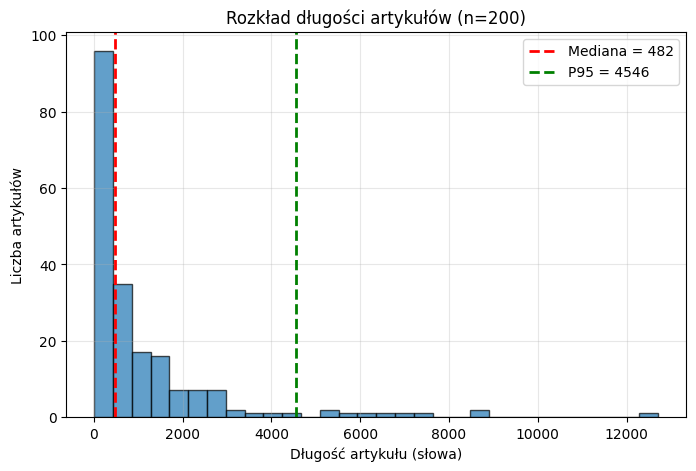


Przybliżenie: 1 słowo ≈ 1.3 tokenu -> maksymalna liczba słów ≈ 393
Liczba artykułów wymagających obcięcia (>393 słów): 111 / 200 (55.5%)


In [ ]:
import re
import numpy as np
import matplotlib.pyplot as plt

def word_count(text):
    if not text:
        return 0
    return len(re.findall(r'\S+', text))

lengths = np.array([word_count(t) for t in texts])

min_len = int(lengths.min())
max_len = int(lengths.max())
mean_len = float(lengths.mean())
median_len = float(np.median(lengths))
std_len = float(lengths.std(ddof=0))
p95 = int(np.percentile(lengths, 95))

print("Min:", min_len)
print("Max:", max_len)
print("Średnia:", round(mean_len,2))
print("Mediana:", round(median_len,2))
print("Odchylenie standardowe:", round(std_len,2))
print("P95:", p95)

plt.figure(figsize=(8,5))
plt.hist(lengths, bins=30, color='C0', edgecolor='black', alpha=0.7)
plt.axvline(median_len, color='red', linestyle='--', linewidth=2, label=f"Mediana = {int(median_len)}")
plt.axvline(p95, color='green', linestyle='--', linewidth=2, label=f"P95 = {p95}")
plt.xlabel('Długość artykułu (słowa)')
plt.ylabel('Liczba artykułów')
plt.title('Rozkład długości artykułów (n=200)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

tokens_per_word = 1.3
max_tokens = 512
max_words_allowed = max_tokens / tokens_per_word  # przybliżenie

num_truncated = int(np.sum(lengths > max_words_allowed))
pct_truncated = float(num_truncated / len(lengths) * 100)

print(f"\nPrzybliżenie: 1 słowo ≈ {tokens_per_word} tokenu -> maksymalna liczba słów ≈ {int(max_words_allowed)}")
print(f"Liczba artykułów wymagających obcięcia (>{int(max_words_allowed)} słów): {num_truncated} / {len(lengths)} ({pct_truncated:.1f}%)")

gdybys chcial/-a przetworzyc te artykuly tokenizatorem BERT
(max_length=512 tokenow), ile artykulow wymagaloby obciecia? Czy to problem?
(szacuj: 1 slowo ~ 1.3 tokenu dla polskiego)

Przy założeniu 1 słowo ~=1.3 liczba artykułów wymagajaca obcięcia to 111/200 - a wiec nieco połowa.

Jeżeli potrzebujemy pełnego kontekstu artykułów ich obcinanie może być problemem. Jeżeli wystarczy jedynie część artykułu - część kontekstu artykułu wtedy obcinanie nie jest problemem.


### Zadanie 4: Tokenizacja polska a angielska
Polszczyzna jest morfologicznie bogata — sprawdz, jak tokenizatory sobie z nia radza.

Wybierz 10 zdan z korpusu (mozesz uzyc pierwszych 10 zdan z pierwszego artykulu).
Dla kazdego zdania zastosuj dwa tokenizatory:
* allegro/herbert-base-cased (WordPiece trenowany na polskim)
* bert-base-multilingual-cased (mBERT — wielojezyczny)
Dla kazdego zdania wyswietl tokeny obu modeli i liczbe tokenow.
Stworz DataFrame (pandas) z kolumnami: zdanie, herbert_n, mbert_n, roznica.
* Narysuj barplot: liczba tokenow herbert vs mbert dla kazdego zdania.

config.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/907k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/556k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/129 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

Zdanie -> herbert tokens (count) | mBERT tokens (count)

AWK – interpretowany język programowania, którego główną funkcją jest wyszukiwanie i przetwarzanie wzorców w plikach lub strumieniach danych.
  HERBERT (26): ['AW', 'K</w>', '–</w>', 'interpre', 'towany</w>', 'język</w>', 'programowania</w>', ',</w>', 'którego</w>', 'główną</w>', 'funkcją</w>', 'jest</w>', 'wyszuki', 'wanie</w>', 'i</w>', 'przetwarz', 'anie</w>', 'wzorców</w>', 'w</w>', 'pli', 'kach</w>', 'lub</w>', 'stru', 'mieniach</w>', 'danych</w>', '.</w>']
  mBERT   (40): ['A', '##W', '##K', '[UNK]', 'inter', '##pret', '##owany', 'język', 'program', '##owania', ',', 'którego', 'g', '##łówną', 'funk', '##cją', 'jest', 'w', '##ys', '##zuki', '##wanie', 'i', 'pr', '##zet', '##war', '##zanie', 'w', '##zor', '##ców', 'w', 'pl', '##ika', '##ch', 'lub', 'str', '##umi', '##enia', '##ch', 'danych', '.']

Jest także nazwą programu początkowo dostępnego dla systemów operacyjnych będących pochodnymi UNIX-a, obecnie także na inne platfo

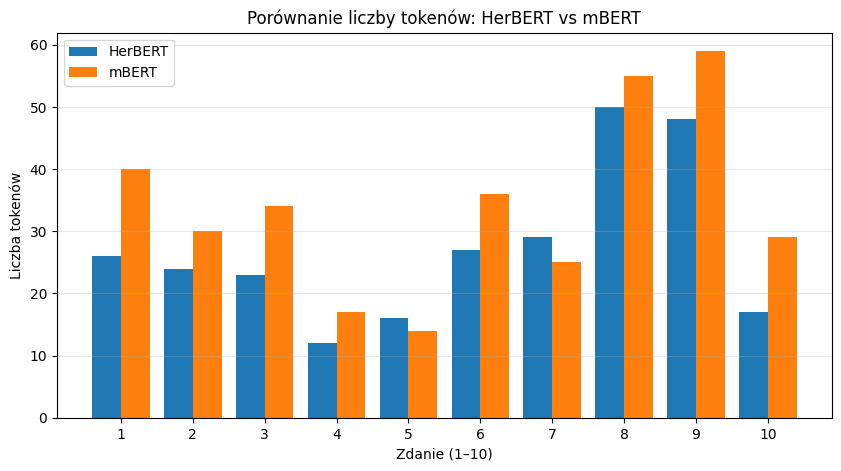

In [ ]:

import re
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer


first_text = texts[0]
sentences = re.split(r'(?<=[\.\!\?])\s+', first_text.strip())
sentences = [s.strip() for s in sentences if s.strip()]
sent10 = sentences[:10]


tok_herbert = AutoTokenizer.from_pretrained("allegro/herbert-base-cased")
tok_mbert   = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")

rows = []
print("Zdanie -> herbert tokens (count) | mBERT tokens (count)\n")
for s in sent10:

    th = tok_herbert.tokenize(s)
    tm = tok_mbert.tokenize(s)
    print(f"{s}\n  HERBERT ({len(th)}): {th}\n  mBERT   ({len(tm)}): {tm}\n")
    rows.append({"zdanie": s, "herbert_n": len(th), "mbert_n": len(tm), "roznica": len(th)-len(tm)})

df = pd.DataFrame(rows)
print(df)


plt.figure(figsize=(10,5))
x = range(len(df))
plt.bar([i-0.2 for i in x], df['herbert_n'], width=0.4, label='HerBERT', color='C0')
plt.bar([i+0.2 for i in x], df['mbert_n'],   width=0.4, label='mBERT',   color='C1')
plt.xticks(x, [f"{i+1}" for i in x])
plt.xlabel('Zdanie (1–10)')
plt.ylabel('Liczba tokenów')
plt.title('Porównanie liczby tokenów: HerBERT vs mBERT')
plt.legend()
plt.grid(alpha=0.3, axis='y')
plt.show()


Wyjasnj, który model jest bardziej 'efektywny' dla polskiego i dlaczego?
Co oznacza wiekszy/mniejszy slownik subslów dla jakosci modelu? <- mozna odpowiedziec w tej komorce pod pytaniem


Model HerBERT jest znacznie bardziej efektywny dla polszczyzny niż wielojęzyczny mBERT, ponieważ jego słownik został wytrenowany wyłącznie na tekstach w języku polskim. Pozwala mu to na poprawne interpretowanie bogatej polskiej fleksji i mapowanie całych wyrazów lub ich naturalnych rdzeni na pojedyncze tokeny, co zapobiega nadmiernej fragmentacji tekstu i skraca sekwencję wejściową. Choć mBERT posiada teoretycznie większy słownik, to ze względu na jego rozproszenie pomiędzy wiele języków drastycznie i nienaturalnie dzieli polskie słowa na drobne cząstki znakowe; z kolei mniejszy, ale wyspecjalizowany słownik HerBERTa zapewnia optymalną kompresję informacji, co odciąża okno kontekstowe sieci i przekłada się na wyższą jakość oraz stabilność działania modelu w zadaniach końcowych.

### Zadanie 5: N-gramy i kolokacje
N-gram to ciag N kolejnych tokenow. Bigram = 2 tokeny, trigram = 3.
Czesc A — bigramy:
* Dla wszystkich 200 artykulow polacz tokeny w liste i oblicz czestotliwosc
bigramow.
* Wyswietl 20 najczestszych bigramow. Czy sa sensowne? Jakie widac wzorce?
Czesc B — trigramy:
* Powtorz dla trigramow (N=3). Wyswietl top 15.
Czesc C — porownanie po usunieciu stopslów:
* Zaladuj liste polskich stopslów: pip install stop_words,
from stop_words import get_stop_words; stopwords = get_stop_words('pl')
* Przefiltruj tokeny i ponownie oblicz top-20 bigramow.

In [ ]:
import re
from collections import Counter
from itertools import islice
import pandas as pd

try:
    from stop_words import get_stop_words
except Exception:
    !pip install stop-words -q
    from stop_words import get_stop_words

stopwords = set(get_stop_words('pl'))


all_text = " ".join(t for t in texts if t)
clean = re.sub(r'[^\wąęćłńóśźżĄĘĆŁŃÓŚŹŻ-]+', ' ', all_text).lower().strip()
tokens = clean.split()

def ngrams(tokens, n):
    return zip(*(tokens[i:] for i in range(n)))

bigram_counts = Counter(ngrams(tokens, 2))
top20_bigrams = bigram_counts.most_common(20)
print("Top 20 bigramów:")
for (a,b),c in top20_bigrams:
    print(f"{a} {b}\t{c}")

trigram_counts = Counter(ngrams(tokens, 3))
top15_trigrams = trigram_counts.most_common(15)
print("\nTop 15 trigramów:")
for (a,b,c),cnt in top15_trigrams:
    print(f"{a} {b} {c}\t{cnt}")


from stop_words import get_stop_words
stopwords = set(get_stop_words('pl'))

filtered_tokens = [t for t in tokens if t not in stopwords]
bigram_counts_filtered = Counter(ngrams(filtered_tokens, 2))
top20_bigrams_filtered = bigram_counts_filtered.most_common(20)
print("\nTop 20 bigramów po usunięciu stop-słów:")
for (a,b),c in top20_bigrams_filtered:
    print(f"{a} {b}\t{c}")


df_bi = pd.DataFrame([{"bigram": f"{a} {b}", "count": c} for (a,b),c in top20_bigrams])
df_bi_filt = pd.DataFrame([{"bigram": f"{a} {b}", "count": c} for (a,b),c in top20_bigrams_filtered])


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 kB 940.9 kB/s eta 0:00:00
Top 20 bigramów:
się w	272
w tym	272
się na	203
się z	191
w latach	171
m in	164
się do	150
a także	133
n e	129
względu na	124
ze względu	114
jak i	105
wraz z	99
zobacz też	97
p n	97
na świecie	92
xx wieku	92
nie jest	89
w wyniku	89
jednym z	89

Top 15 trigramów:
ze względu na	113
p n e	97
w tym samym	52
przypisy linki zewnętrzne	43
po raz pierwszy	37
w związku z	35
m n p	34
n p m	34
w ten sposób	33
w stanach zjednoczonych	32
ii wojny światowej	28
tym samym roku	27
jest jednym z	27
co do wielkości	26
składa się z	24

Top 20 bigramów po usunięciu stop-słów:
m in	164
n e	129
p n	98
xx wieku	92
linki zewnętrzne	87
przypisy bibliografia	69
stanów zjednoczonych	68
xix wieku	52
armii krajowej	50
m n	48
wojny światowej	47
przypisy linki	43
p m	40
stanach zjednoczonych	38
wielkiej brytanii	37
wyd pol	37
n p	36
sił zbrojnych	29
buenos aires	28
apollo 11	26


Jak stopwords wplywaja na sensownosc kolokacji? Kiedy je usuwac,
a kiedy zostawic (podpowiedz: dependency parsing, modele jezykowe)? <-odpowiedz

In [ ]:
Jak stop-słowa wpływają na sensowność kolokacji?

Usunięcie stop-słów zwykle ujawnia semantycznie bogatsze kolokacje (np. rzeczownik+rzeczownik, przymiotnik+rzeczownik),
ponieważ frazy funkcyjne przeważają liczebnie i „zasłaniają” informacyjne pary.

Kiedy usuwać stop-słowa: gdy celem jest wykrycie semantycznych kolokacji, tematów, często występujących fraz leksykalnych lub gdy budujesz słowniki fraz.

Kiedy zostawić stop-słowa: gdy analizujesz zależności składniowe (dependency parsing), konstrukcje gramatyczne,
lub gdy model/architektura oczekuje pełnego kontekstu (np. language modeling, gdzie obecność przyimków/funkcji jest istotna).
Stop-słowa mogą być też ważne przy ekstrakcji fraz wzorcowych i w zadaniach, gdzie szyk i spójnikowanie mają znaczenie.


###Wnioski


Przeprowadzone laboratorium dowodzi, że eksploracyjna analiza statystyczna korpusu (Text EDA) jest kluczowym etapem przed wdrożeniem modeli językowych, pozwalającym wykryć anomalie w rozkładzie długości tekstów oraz empirycznie potwierdzić prawo Zipfa, według którego wąska grupa słów funkcyjnych determinuje większość struktur wejściowych. Analiza limitów okna kontekstowego wykazała, że sztywne ograniczenie do 512 tokenów wymusiłoby skrócenie ponad połowy badanych artykułów z Wikipedii, co w zadaniach wymagających modelowania długodystansowego (np. QA czy streszczanie) prowadziłoby do bezpowrotnej utraty kluczowych informacji. Ostatecznie, bezpośrednie porównanie procesów tokenizacji jednoznacznie wskazuje na wyższą efektywność dedykowanego modelu HerBERT nad wielojęzycznym mBERT – mniejszy, lecz ściśle wyspecjalizowany pod kątem polskiej fleksji słownik subwyrazowy zapewnia optymalną kompresję tekstu, co zapobiega nadmiernej fragmentacji wyrazów, odciąża pamięć modelu i bezpośrednio przekłada się na wyższą stabilność w zadaniach końcowych, natomiast usunięcie stop-words pozwala wydobyć z korpusu faktyczne, wartościowe semantycznie kolokacje i N-gramy.